In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from chronos import Chronos2Pipeline

In [10]:
CSV_PATH = "../data/raw/btc_usd_1min.csv"
CONTEXT_LENGTH = 512
PREDICTION_LENGTH = 60

df = pd.read_csv(CSV_PATH)

close_prices = df["Close"]

context = (
    close_prices.iloc[-CONTEXT_LENGTH:]
    .to_numpy()
    .copy()
    .reshape(1, 1, -1)
)

print("Context length:", context.shape)

Context length: 1


In [6]:
pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2"
)

print("Chronos-2 loaded")

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 8103.74it/s]

Chronos-2 loaded


In [14]:
forecast = pipeline.predict(
    context,
    prediction_length=PREDICTION_LENGTH
)

print(type(forecast))

<class 'list'>


In [15]:
forecast_tensor = forecast[0]

print("Shape:", forecast_tensor.shape)

Shape: torch.Size([1, 21, 60])


In [16]:
samples = forecast_tensor[0]

print("Samples shape:", samples.shape)

Samples shape: torch.Size([21, 60])


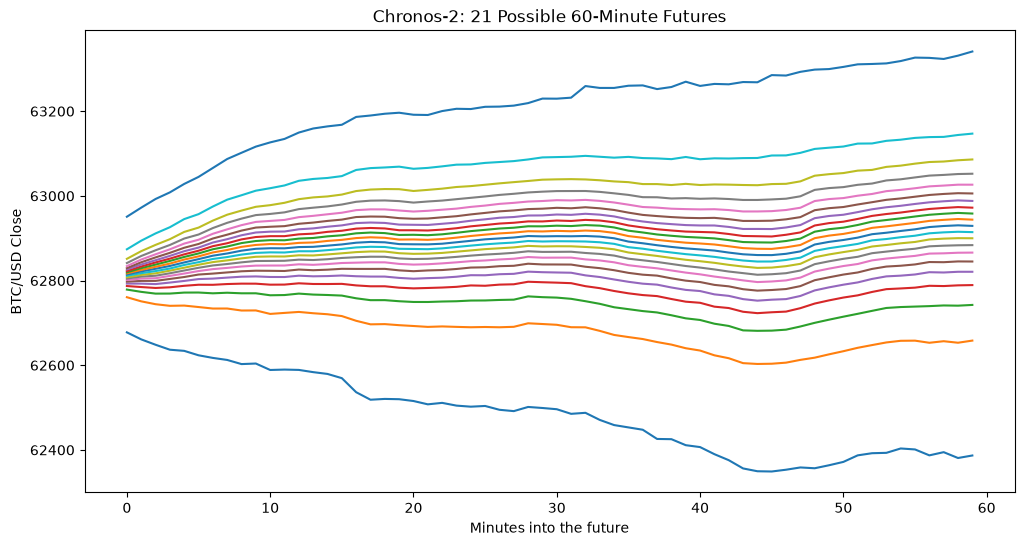

In [20]:
samples = forecast[0][0]

plt.figure(figsize=(12, 6))

for sample in samples:
    plt.plot(sample.numpy())

plt.xlabel("Minutes into the future")
plt.ylabel("BTC/USD Close")
plt.title("Chronos-2: 21 Possible 60-Minute Futures")
plt.show()

In [19]:
median_forecast = samples.median(dim=0).values

print("Median forecast shape:", median_forecast.shape)

Median forecast shape: torch.Size([60])


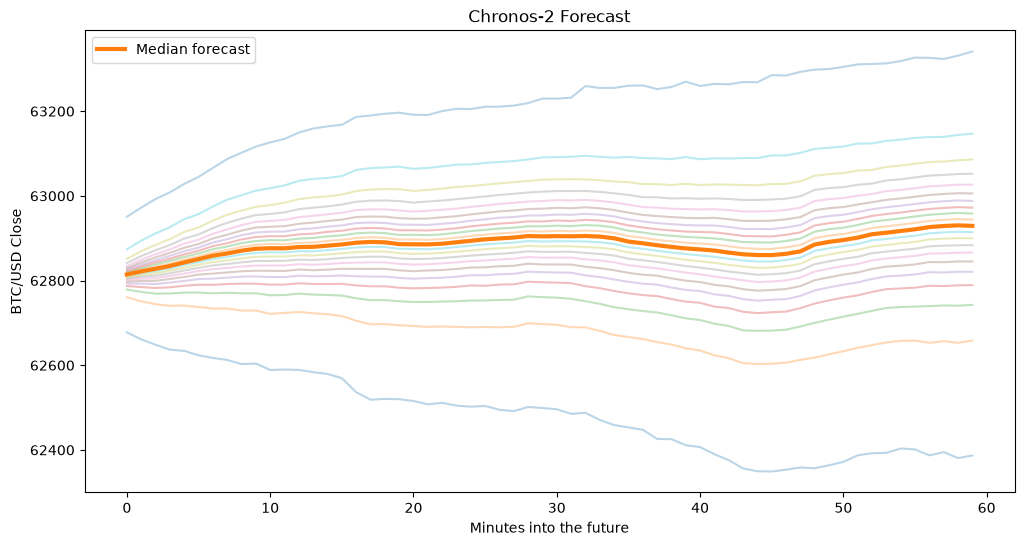

In [21]:
plt.figure(figsize=(12, 6))

for sample in samples:
    plt.plot(sample.numpy(), alpha=0.3)

plt.plot(
    median_forecast.numpy(),
    linewidth=3,
    label="Median forecast",
)

plt.xlabel("Minutes into the future")
plt.ylabel("BTC/USD Close")
plt.title("Chronos-2 Forecast")
plt.legend()
plt.show()

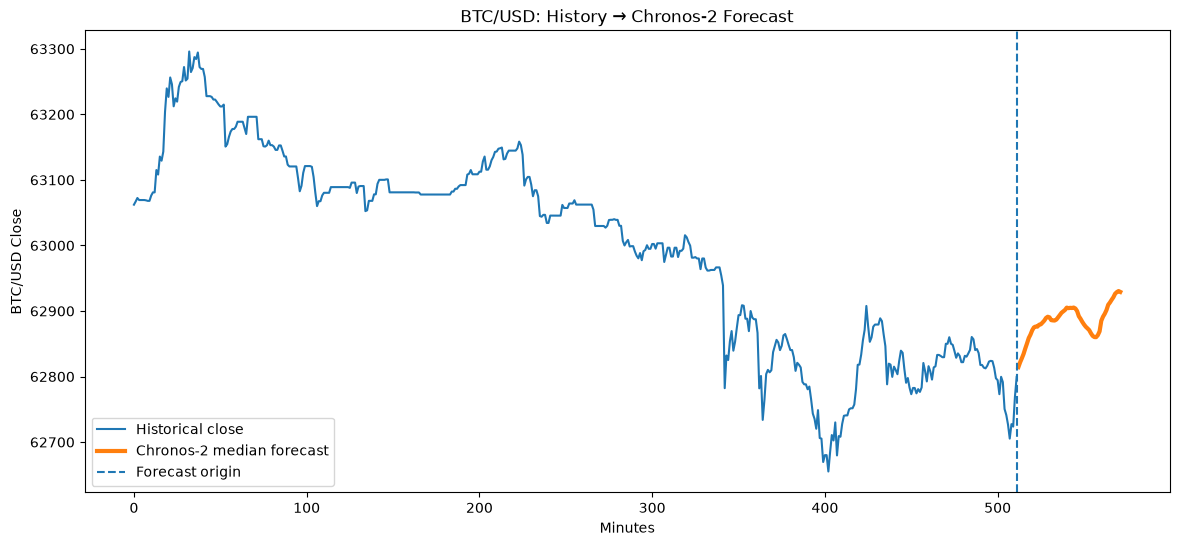

In [22]:
history = context[0, 0]

plt.figure(figsize=(14, 6))

# Historical BTC prices
plt.plot(
    range(len(history)),
    history,
    label="Historical close",
)

# Chronos median forecast
plt.plot(
    range(len(history), len(history) + len(median_forecast)),
    median_forecast.numpy(),
    linewidth=3,
    label="Chronos-2 median forecast",
)

plt.axvline(
    len(history) - 1,
    linestyle="--",
    label="Forecast origin",
)

plt.xlabel("Minutes")
plt.ylabel("BTC/USD Close")
plt.title("BTC/USD: History → Chronos-2 Forecast")
plt.legend()
plt.show()

In [23]:
lower = samples.quantile(0.10, dim=0)
upper = samples.quantile(0.90, dim=0)

print("Lower shape:", lower.shape)
print("Upper shape:", upper.shape)

Lower shape: torch.Size([60])
Upper shape: torch.Size([60])


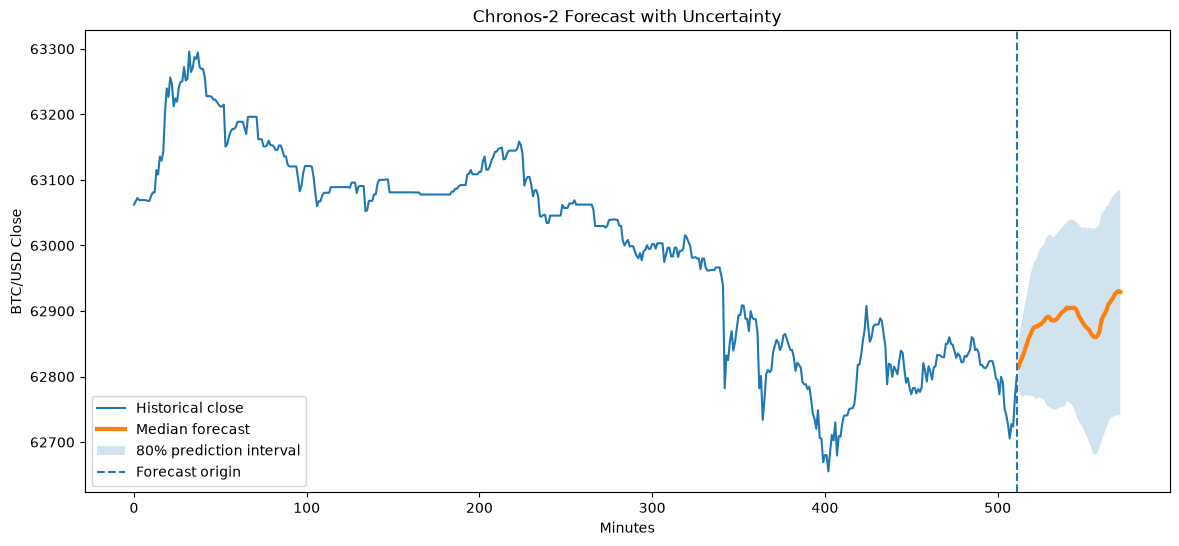

In [25]:
plt.figure(figsize=(14, 6))

history = context[0, 0]

future_x = range(len(history), len(history) + len(median_forecast))

plt.plot(
    range(len(history)),
    history,
    label="Historical close",
)

plt.plot(
    future_x,
    median_forecast.numpy(),
    linewidth=3,
    label="Median forecast",
)

plt.fill_between(
    future_x,
    lower.numpy(),
    upper.numpy(),
    alpha=0.2,
    label="80% prediction interval",
)

plt.axvline(
    len(history) - 1,
    linestyle="--",
    label="Forecast origin",
)

plt.xlabel("Minutes")
plt.ylabel("BTC/USD Close")
plt.title("Chronos-2 Forecast with Uncertainty")
plt.legend()
plt.show()

In [26]:
last_close = context[0, 0, -1]

naive_forecast = [last_close] * PREDICTION_LENGTH

print("Last known close:", last_close)
print("Naive forecast length:", len(naive_forecast))
print("First prediction:", naive_forecast[0])
print("Last prediction:", naive_forecast[-1])

Last known close: 62799.46
Naive forecast length: 60
First prediction: 62799.46
Last prediction: 62799.46


In [27]:
EVAL_END = len(df) - PREDICTION_LENGTH

print("Evaluation end index:", EVAL_END)
print("Total rows:", len(df))

Evaluation end index: 7692449
Total rows: 7692509


In [29]:
context_start = EVAL_END - CONTEXT_LENGTH

evaluation_context = (
    df["Close"]
    .iloc[context_start:EVAL_END]
    .to_numpy()
    .copy()
    .reshape(1, 1, -1)
)

actual_future = (
    df["Close"]
    .iloc[EVAL_END:EVAL_END + PREDICTION_LENGTH]
    .to_numpy()
)

print("Context shape:", evaluation_context.shape)
print("Actual future shape:", actual_future.shape)
print("Latest known close:", evaluation_context[0, 0, -1])
print("First actual future price:", actual_future[0])
print("Last actual future price:", actual_future[-1])

Context shape: (1, 1, 512)
Actual future shape: (60,)
Latest known close: 62782.59
First actual future price: 62782.58
Last actual future price: 62799.46


In [30]:
chronos_forecast = pipeline.predict(
    evaluation_context,
    prediction_length=PREDICTION_LENGTH,
)

chronos_samples = chronos_forecast[0][0]

chronos_median = chronos_samples.median(dim=0).values

print("Chronos samples shape:", chronos_samples.shape)
print("Chronos median shape:", chronos_median.shape)

Chronos samples shape: torch.Size([21, 60])
Chronos median shape: torch.Size([60])


In [31]:
evaluation_last_close = evaluation_context[0, 0, -1]

naive_evaluation = [evaluation_last_close] * PREDICTION_LENGTH

print("Naive forecast length:", len(naive_evaluation))

Naive forecast length: 60


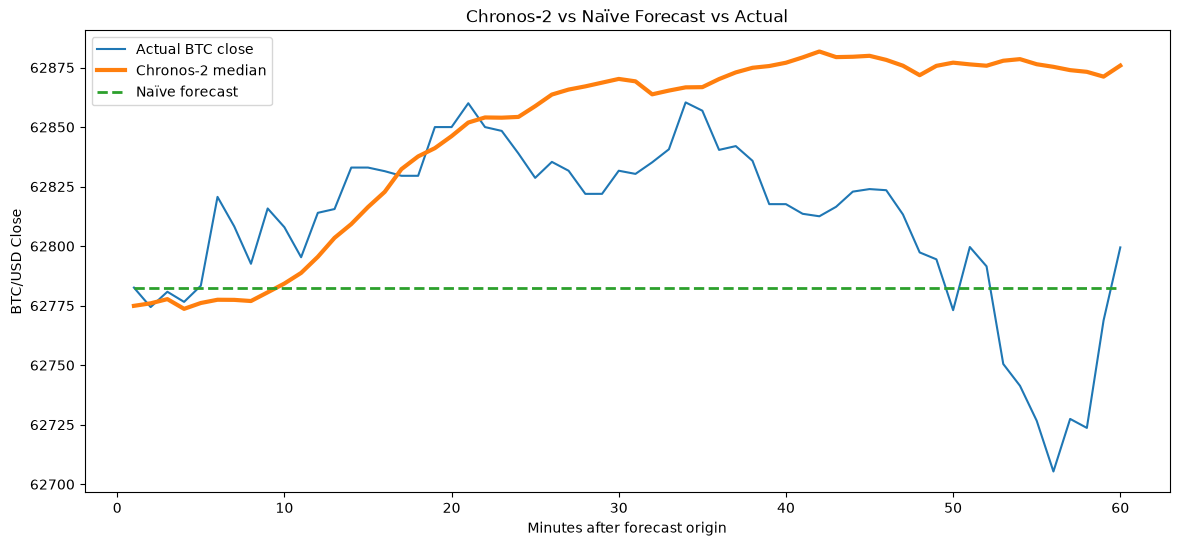

In [32]:
import numpy as np
import matplotlib.pyplot as plt


future_minutes = np.arange(1, PREDICTION_LENGTH + 1)

plt.figure(figsize=(14, 6))

plt.plot(
    future_minutes,
    actual_future,
    label="Actual BTC close",
)

plt.plot(
    future_minutes,
    chronos_median.numpy(),
    linewidth=3,
    label="Chronos-2 median",
)

plt.plot(
    future_minutes,
    naive_evaluation,
    linestyle="--",
    linewidth=2,
    label="Naïve forecast",
)

plt.xlabel("Minutes after forecast origin")
plt.ylabel("BTC/USD Close")
plt.title("Chronos-2 vs Naïve Forecast vs Actual")
plt.legend()
plt.show()

In [33]:
chronos_mae = np.mean(
    np.abs(chronos_median.numpy() - actual_future)
)

naive_mae = np.mean(
    np.abs(np.array(naive_evaluation) - actual_future)
)

print(f"Chronos-2 MAE: ${chronos_mae:.2f}")
print(f"Naïve MAE:      ${naive_mae:.2f}")

Chronos-2 MAE: $46.15
Naïve MAE:      $39.33


In [44]:
N_ORIGINS = 100
ORIGIN_STEP = PREDICTION_LENGTH

last_possible_origin = len(df) - PREDICTION_LENGTH

origins = np.arange(
    last_possible_origin - (N_ORIGINS - 1) * ORIGIN_STEP,
    last_possible_origin + 1,
    ORIGIN_STEP,
)

print("Number of origins:", len(origins))
print("Origins:", origins)

Number of origins: 100
Origins: [7686509 7686569 7686629 7686689 7686749 7686809 7686869 7686929 7686989
 7687049 7687109 7687169 7687229 7687289 7687349 7687409 7687469 7687529
 7687589 7687649 7687709 7687769 7687829 7687889 7687949 7688009 7688069
 7688129 7688189 7688249 7688309 7688369 7688429 7688489 7688549 7688609
 7688669 7688729 7688789 7688849 7688909 7688969 7689029 7689089 7689149
 7689209 7689269 7689329 7689389 7689449 7689509 7689569 7689629 7689689
 7689749 7689809 7689869 7689929 7689989 7690049 7690109 7690169 7690229
 7690289 7690349 7690409 7690469 7690529 7690589 7690649 7690709 7690769
 7690829 7690889 7690949 7691009 7691069 7691129 7691189 7691249 7691309
 7691369 7691429 7691489 7691549 7691609 7691669 7691729 7691789 7691849
 7691909 7691969 7692029 7692089 7692149 7692209 7692269 7692329 7692389
 7692449]


In [45]:
results = []

for origin in origins:
    context_start = origin - CONTEXT_LENGTH

    evaluation_context = (
        df["Close"]
        .iloc[context_start:origin]
        .to_numpy()
        .copy()
        .reshape(1, 1, -1)
    )

    actual_future = (
        df["Close"]
        .iloc[origin:origin + PREDICTION_LENGTH]
        .to_numpy()
    )

    # Chronos-2 forecast
    chronos_output = pipeline.predict(
        evaluation_context,
        prediction_length=PREDICTION_LENGTH,
    )

    chronos_samples = chronos_output[0][0]
    chronos_median = chronos_samples.median(dim=0).values

    # Naïve forecast
    last_close = evaluation_context[0, 0, -1]
    naive_forecast = np.full(PREDICTION_LENGTH, last_close)

    # MAE
    chronos_mae = np.mean(
        np.abs(chronos_median.numpy() - actual_future)
    )

    naive_mae = np.mean(
        np.abs(naive_forecast - actual_future)
    )

    results.append({
        "origin": origin,
        "chronos_mae": chronos_mae,
        "naive_mae": naive_mae,
    })

    print(
        f"Origin {origin}: "
        f"Chronos MAE = ${chronos_mae:.2f}, "
        f"Naïve MAE = ${naive_mae:.2f}"
    )

Origin 7686509: Chronos MAE = $49.48, Naïve MAE = $48.87
Origin 7686569: Chronos MAE = $23.43, Naïve MAE = $27.78
Origin 7686629: Chronos MAE = $87.89, Naïve MAE = $82.67
Origin 7686689: Chronos MAE = $93.73, Naïve MAE = $91.75
Origin 7686749: Chronos MAE = $78.63, Naïve MAE = $69.46
Origin 7686809: Chronos MAE = $41.83, Naïve MAE = $49.39
Origin 7686869: Chronos MAE = $71.90, Naïve MAE = $73.16
Origin 7686929: Chronos MAE = $50.92, Naïve MAE = $51.59
Origin 7686989: Chronos MAE = $190.07, Naïve MAE = $188.56
Origin 7687049: Chronos MAE = $63.48, Naïve MAE = $64.98
Origin 7687109: Chronos MAE = $72.98, Naïve MAE = $55.50
Origin 7687169: Chronos MAE = $37.27, Naïve MAE = $37.15
Origin 7687229: Chronos MAE = $84.68, Naïve MAE = $59.81
Origin 7687289: Chronos MAE = $50.03, Naïve MAE = $46.92
Origin 7687349: Chronos MAE = $37.98, Naïve MAE = $33.94
Origin 7687409: Chronos MAE = $25.26, Naïve MAE = $58.54
Origin 7687469: Chronos MAE = $72.90, Naïve MAE = $90.22
Origin 7687529: Chronos MAE =

In [46]:
results_df = pd.DataFrame(results)

results_df

,origin,chronos_mae,naive_mae
0,7686509,49.478385,48.868167
1,7686569,23.432380,27.782167
2,7686629,87.893893,82.674500
3,7686689,93.734091,91.754667
4,7686749,78.630096,69.461667
...,...,...,...
95,7692209,75.386583,69.463000
96,7692269,35.228708,31.472167
97,7692329,99.367664,107.183667
98,7692389,83.472333,57.190333


In [47]:
mean_chronos_mae = results_df["chronos_mae"].mean()
mean_naive_mae = results_df["naive_mae"].mean()

print(f"Average Chronos-2 MAE: ${mean_chronos_mae:.2f}")
print(f"Average Naïve MAE:      ${mean_naive_mae:.2f}")

Average Chronos-2 MAE: $54.87
Average Naïve MAE:      $52.80


In [48]:
chronos_wins = (
    results_df["chronos_mae"] < results_df["naive_mae"]
).sum()

win_rate = chronos_wins / len(results_df)

print(f"Chronos wins: {chronos_wins}/{len(results_df)}")
print(f"Chronos win rate: {win_rate:.1%}")

Chronos wins: 40/100
Chronos win rate: 40.0%


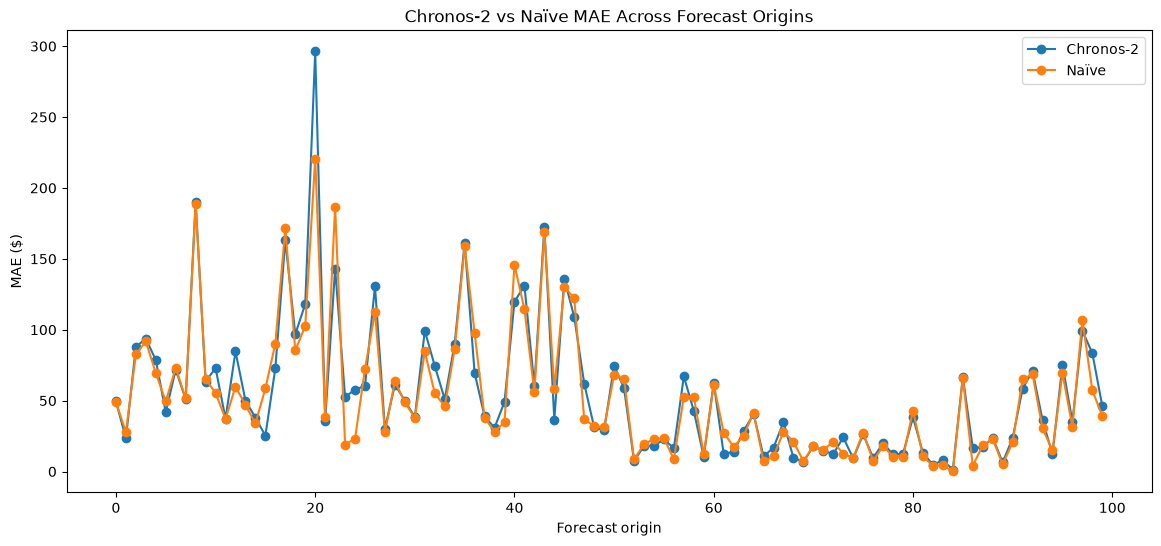

In [49]:
plt.figure(figsize=(14, 6))

plt.plot(
    results_df.index,
    results_df["chronos_mae"],
    marker="o",
    label="Chronos-2",
)

plt.plot(
    results_df.index,
    results_df["naive_mae"],
    marker="o",
    label="Naïve",
)

plt.xlabel("Forecast origin")
plt.ylabel("MAE ($)")
plt.title("Chronos-2 vs Naïve MAE Across Forecast Origins")
plt.legend()
plt.show()